# K-Prototypes


Data shape: (100798, 37)
Numerical features: 1 (indices 0-0)
Categorical features: 36 (indices 1-36)

Finding optimal K...
Testing K=2... Cost: 15346666.17
Testing K=3... Cost: 9492698.08
Testing K=4... Cost: 7437457.00
Testing K=5... Cost: 6466673.32
Testing K=6... Cost: 5933172.23
Testing K=7... Cost: 5574939.47
Testing K=8... Cost: 5305746.57
Testing K=9... Cost: 5020137.12
Testing K=10... Cost: 4832883.84


C:\Users\Beckh\AppData\Local\Temp\ipykernel_38004\372461967.py:90: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K_range, costs, 'bo-', marker='o', linewidth=2, markersize=8)


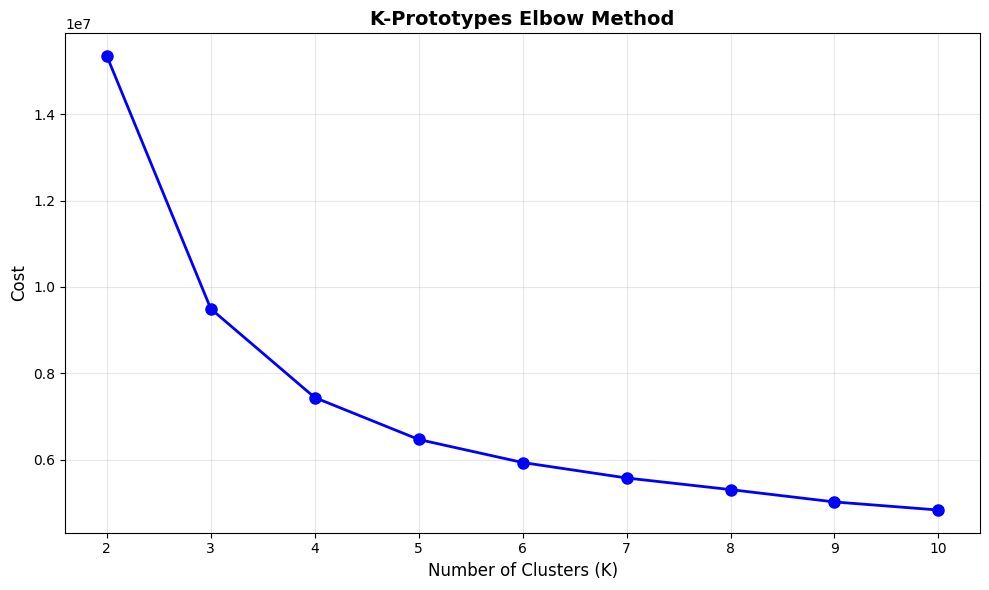

In [33]:
# import libraries
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes

# import pre-processed dataset
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop useless columns
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

# Define feature groups
# Already one-hot encoded features
encoded_categorical = [
    'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined',
    'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 
    'Education_Some college', 'Education_Unknown',
    'Sex_Female', 'Sex_Male',
    'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 
    'Race_Native American/Native Alaskan', 'Race_White',
    'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction',
    'Place of incident_Other specified', 'Place of incident_Other unspecified', 
    'Place of incident_Residential institution', 'Place of incident_School/instiution',
    'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area',
    'Place of incident_Unspecified',
    'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 
    'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
    'Police involvement', 'isWeekend' 
]

# Numerical features to scale (removed Month and Hispanic)
num_features = ["Age"]

# Combine all features for clustering
all_features = encoded_categorical + num_features
df_cluster = df[all_features].copy()

# --- Preprocess (only need to scale numerical features) ---
# Categorical features are already encoded, so no imputation/encoding needed
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

pre = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", "passthrough", encoded_categorical)
], remainder="drop")

# --- Pick K (elbow method) and fit K-Prototypes ---

# Prepare data for K-Prototypes (no preprocessing needed - use raw data)

# Reorder: numerical first, then categorical
ordered_cols = num_features + encoded_categorical
X_kproto = df_cluster[ordered_cols].values

# Handle missing values in Age (if any)
from sklearn.impute import SimpleImputer
age_imputer = SimpleImputer(strategy='median')
X_kproto[:, :len(num_features)] = age_imputer.fit_transform(X_kproto[:, :len(num_features)])

# Categorical features start after numerical ones
categorical_indices = list(range(len(num_features), X_kproto.shape[1]))

print(f"\nData shape: {X_kproto.shape}")
print(f"Numerical features: {len(num_features)} (indices 0-{len(num_features)-1})")
print(f"Categorical features: {len(encoded_categorical)} (indices {len(num_features)}-{X_kproto.shape[1]-1})")

# Find optimal K using cost (elbow method)
costs = []
K_range = range(2, 11)

print("\nFinding optimal K...")
for k in K_range:
    print(f"Testing K={k}...", end=" ")
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=3244, verbose=0, n_init=5)
    kproto.fit(X_kproto, categorical=categorical_indices)
    costs.append(kproto.cost_)
    print(f"Cost: {kproto.cost_:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-', marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('K-Prototypes Elbow Method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()



## k = 4


Using K=4 clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 27848, ncost: 8639004.145741679
Run: 1, iteration: 2/100, moves: 11581, ncost: 8016168.573570898
Run: 1, iteration: 3/100, moves: 7411, ncost: 7790989.915331657
Run: 1, iteration: 4/100, moves: 5541, ncost: 7666527.790958659
Run: 1, iteration: 5/100, moves: 4245, ncost: 7594380.939913698
Run: 1, iteration: 6/100, moves: 3811, ncost: 7534699.970798528
Run: 1, iteration: 7/100, moves: 3175, ncost: 7491318.03694777
Run: 1, iteration: 8/100, moves: 2021, ncost: 7473659.60277574
Run: 1, iteration: 9/100, moves: 1724, ncost: 7461053.698058376
Run: 1, iteration: 10/100, moves: 106, ncost: 7460999.476160716
Run: 1, iteration: 11/100, moves: 0, ncost: 7460999.476160716
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 21317, ncost: 7690188.503824771
Run: 2, iteration: 2/100, moves: 7762, ncost: 7466878

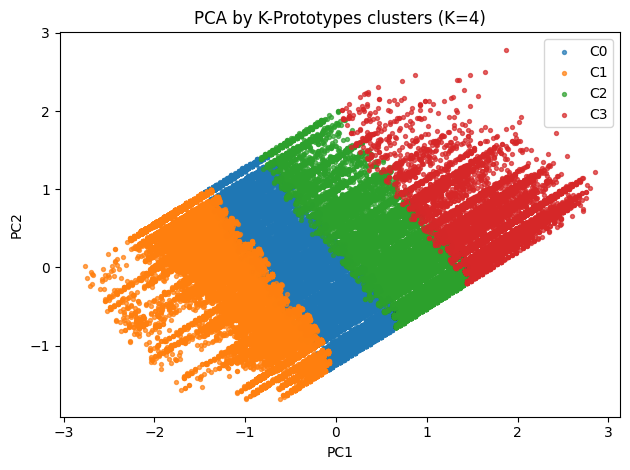


CLUSTER PROFILE FOR K=4

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 25,397 ( 25.2%)
Cluster 1: 33,301 ( 33.0%)
Cluster 2: 27,429 ( 27.2%)
Cluster 3: 14,671 ( 14.6%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        25397  39.90   40.0
1        33301  23.97   24.0
2        27429  57.09   57.0
3        14671  77.97   77.0

3. POLICE INVOLVEMENT DISTRIBUTION
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.981                   0.019
1                        0.981                   0.019
2                        0.991                   0.009
3                        0.998                   0.002

4. WEEKEND DISTRIBUTION
--------------------------------------------------
         Weekend=Weekday  Week

In [35]:
# Choose optimal K (you can adjust this based on the elbow plot)
best_k = 4  # Change this if you see a different elbow point

print(f"\nUsing K={best_k} clusters")

# Fit final K-Prototypes model
kproto_final = KPrototypes(n_clusters=best_k, init='Huang', random_state=3244, verbose=2, n_init=10)
labels = kproto_final.fit_predict(X_kproto, categorical=categorical_indices)

print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(labels)*100:.1f}%)")

# For PCA visualization, we need to standardize the data
# (K-Prototypes works on raw data, but PCA needs scaled data)
df_pre = pre.fit_transform(df_cluster)

# ============================================
# CLUSTER EVALUATION METRICS
# ============================================
print(f"\n{'='*60}")
print(f"CLUSTER EVALUATION METRICS")
print(f"{'='*60}")

# 1. Cost (from K-Prototypes)
print(f"K-Prototypes Cost: {kproto_final.cost_:.2f}")

# 2. Silhouette Score with Gower distance (for mixed data) **ran out of memory on large dataset**
# try:
#     import gower
#     distance_matrix = gower.gower_matrix(X_kproto)
#     silhouette_gower = silhouette_score(distance_matrix, labels, metric='precomputed')
#     print(f"Silhouette Score (Gower): {silhouette_gower:.4f} (range: -1 to 1, higher is better)")
# except ImportError:
#     print("Silhouette Score (Gower): Install 'gower' package to compute")

# 3. Davies-Bouldin Index (on preprocessed data)
db_score = davies_bouldin_score(df_pre, labels)
print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")

# 4. Calinski-Harabasz Score (on preprocessed data)
ch_score = calinski_harabasz_score(df_pre, labels)
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

print(f"\n{'='*60}")

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster == c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend()
plt.title(f"PCA by K-Prototypes clusters (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Cluster Profile Table ---
# Create a summary dataframe with decoded categorical variables for interpretation
df_summary = df.copy()
df_summary["cluster"] = labels

# Decode one-hot encoded features back to categorical for profiling
df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')
df_summary["Police_involvement"] = df_summary["Police involvement"].map({0: "No", 1: "Yes"})
df_summary["Weekend"] = df_summary["isWeekend"].map({0: "Weekday", 1: "Weekend"})

# Numerical summaries
num_summary = df_summary.groupby("cluster")[["Age"]].agg(["count", "mean", "median"]).round(2)

# Categorical proportion tables
def prop_table(data, col):

    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    
    tab.columns = [f"{col}={c}" for c in tab.columns]

    return tab.round(3)

cat_summary = pd.concat([
    prop_table(df_summary, "Race"),
    prop_table(df_summary, "Education"),
    prop_table(df_summary, "Place_of_incident"),
    prop_table(df_summary, "Reason"),
    prop_table(df_summary, "Day_of_week"),
    prop_table(df_summary, "Sex"),
    prop_table(df_summary, "Police_involvement"),
    prop_table(df_summary, "Weekend") 
], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()

# Print Cluster Profile
print("\n" + "="*70)
print(f"CLUSTER PROFILE FOR K={best_k}")
print("="*70)

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes = df_summary['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = (size / len(df_summary)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary[['Age']])

# 3. Police Involvement (categorical proportions)
print("\n3. POLICE INVOLVEMENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Police_involvement='))

# 4. Weekend Pattern (categorical proportions)
print("\n4. WEEKEND DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Weekend='))

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Sex='))

print("\n" + "="*70)

## k = 5


Using K=5 clusters
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 16991, ncost: 6638802.483601897
Run: 1, iteration: 2/100, moves: 4865, ncost: 6596929.635696424
Run: 1, iteration: 3/100, moves: 3260, ncost: 6563740.949579108
Run: 1, iteration: 4/100, moves: 2525, ncost: 6545774.426448621
Run: 1, iteration: 5/100, moves: 3358, ncost: 6516473.23678001
Run: 1, iteration: 6/100, moves: 1351, ncost: 6511911.574371378
Run: 1, iteration: 7/100, moves: 0, ncost: 6511911.574371378
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 28301, ncost: 7147738.904941744
Run: 2, iteration: 2/100, moves: 15339, ncost: 6664163.120048311
Run: 2, iteration: 3/100, moves: 7140, ncost: 6544846.732265332
Run: 2, iteration: 4/100, moves: 3679, ncost: 6503480.727298642
Run: 2, iteration: 5/100, moves: 541, ncost: 6502792.946307302
Run: 2, iteration: 6/100, moves: 0, ncost: 6502792.946

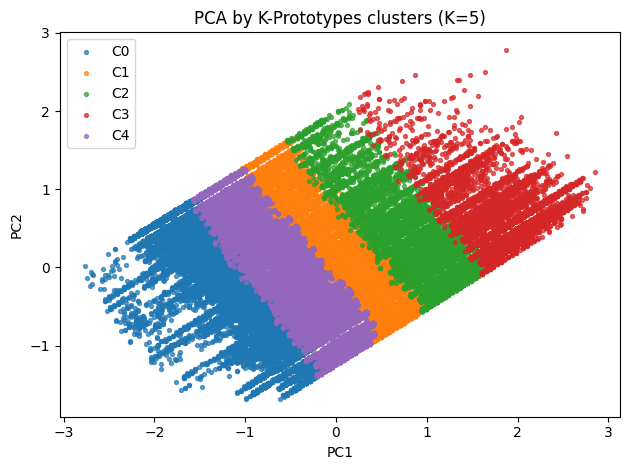


CLUSTER PROFILE FOR K=5

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 27,854 ( 27.6%)
Cluster 1: 20,653 ( 20.5%)
Cluster 2: 19,098 ( 18.9%)
Cluster 3: 11,176 ( 11.1%)
Cluster 4: 22,017 ( 21.8%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        27854  22.69   23.0
1        20653  49.23   49.0
2        19098  62.50   62.0
3        11176  80.62   80.0
4        22017  35.34   35.0

3. POLICE INVOLVEMENT DISTRIBUTION
--------------------------------------------------
         Police_involvement=No  Police_involvement=Yes
cluster                                               
0                        0.982                   0.018
1                        0.986                   0.014
2                        0.994                   0.006
3                        0.999                   0.001
4                        0.979                   0

In [ ]:
# Choose optimal K (you can adjust this based on the elbow plot)
best_k = 5  # Change this if you see a different elbow point

print(f"\nUsing K={best_k} clusters")

# Fit final K-Prototypes model
kproto_final = KPrototypes(n_clusters=best_k, init='Huang', random_state=3244, verbose=2, n_init=10)
labels = kproto_final.fit_predict(X_kproto, categorical=categorical_indices)

print(f"\nCluster distribution:")
unique, counts = np.unique(labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(labels)*100:.1f}%)")

# For PCA visualization, we need to standardize the data
# (K-Prototypes works on raw data, but PCA needs scaled data)
df_pre = pre.fit_transform(df_cluster)

# ============================================
# CLUSTER EVALUATION METRICS
# ============================================
print(f"\n{'='*60}")
print(f"CLUSTER EVALUATION METRICS")
print(f"{'='*60}")

# 1. Cost (from K-Prototypes)
print(f"K-Prototypes Cost: {kproto_final.cost_:.2f}")

# 2. Silhouette Score with Gower distance (for mixed data) **ran out of memory on large dataset**
# try:
#     import gower
#     distance_matrix = gower.gower_matrix(X_kproto)
#     silhouette_gower = silhouette_score(distance_matrix, labels, metric='precomputed')
#     print(f"Silhouette Score (Gower): {silhouette_gower:.4f} (range: -1 to 1, higher is better)")
# except ImportError:
#     print("Silhouette Score (Gower): Install 'gower' package to compute")

# 3. Davies-Bouldin Index (on preprocessed data)
db_score = davies_bouldin_score(df_pre, labels)
print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")

# 4. Calinski-Harabasz Score (on preprocessed data)
ch_score = calinski_harabasz_score(df_pre, labels)
print(f"Calinski-Harabasz Score: {ch_score:.2f} (higher is better)")

print(f"\n{'='*60}")

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster == c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend()
plt.title(f"PCA by K-Prototypes clusters (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Cluster Profile Table ---
# Create a summary dataframe with decoded categorical variables for interpretation
df_summary = df.copy()
df_summary["cluster"] = labels

# Decode one-hot encoded features back to categorical for profiling
df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')
df_summary["Police_involvement"] = df_summary["Police involvement"].map({0: "No", 1: "Yes"})
df_summary["Weekend"] = df_summary["isWeekend"].map({0: "Weekday", 1: "Weekend"})

# Numerical summaries
num_summary = df_summary.groupby("cluster")[["Age"]].agg(["count", "mean", "median"]).round(2)

# Categorical proportion tables
def prop_table(data, col):

    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    
    tab.columns = [f"{col}={c}" for c in tab.columns]

    return tab.round(3)

cat_summary = pd.concat([
    prop_table(df_summary, "Race"),
    prop_table(df_summary, "Education"),
    prop_table(df_summary, "Place_of_incident"),
    prop_table(df_summary, "Reason"),
    prop_table(df_summary, "Day_of_week"),
    prop_table(df_summary, "Sex"),
    prop_table(df_summary, "Police_involvement"),
    prop_table(df_summary, "Weekend") 
], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()

# Print Cluster Profile
print("\n" + "="*70)
print(f"CLUSTER PROFILE FOR K={best_k}")
print("="*70)

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes = df_summary['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = (size / len(df_summary)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary[['Age']])

# 3. Police Involvement (categorical proportions)
print("\n3. POLICE INVOLVEMENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Police_involvement='))

# 4. Weekend Pattern (categorical proportions)
print("\n4. WEEKEND DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Weekend='))

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Sex='))

print("\n" + "="*70)

# K-Means

## Cluster profile for best k

Best K: 4 silhouette: 0.205


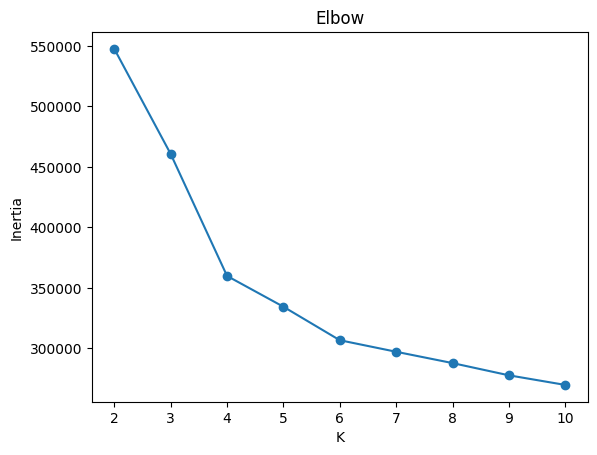

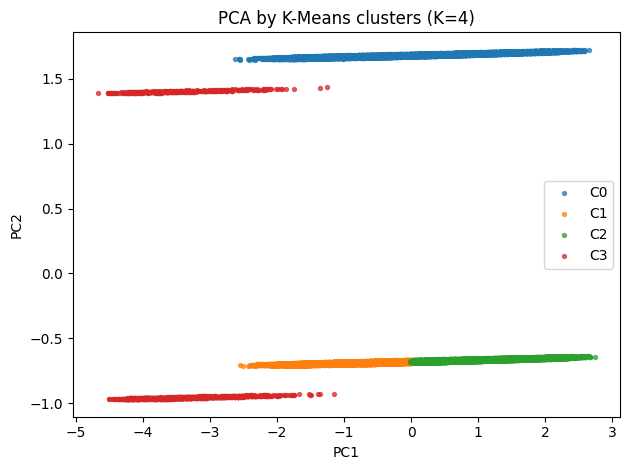


CLUSTER PROFILE FOR K=4

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 28,690 ( 28.5%)
Cluster 1: 34,786 ( 34.5%)
Cluster 2: 35,920 ( 35.6%)
Cluster 3:  1,402 (  1.4%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        28690  44.90   43.0
1        34786  29.25   28.0
2        35920  60.24   59.0
3         1402  37.05   35.0

3. POLICE INVOLVEMENT
--------------------------------------------------
        Police involvement            
                     count mean median
cluster                               
0                    28690  0.0    0.0
1                    34786  0.0    0.0
2                    35920  0.0    0.0
3                     1402  1.0    1.0

4. WEEKEND PATTERN
--------------------------------------------------
        isWeekend             
            count  mean median
cluster                       
0           

In [ ]:
# import libraries
import pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# import pre-processed dataset
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop useless columns
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

# Define feature groups
# Already one-hot encoded features
encoded_categorical = [
    'Reason_Accidental', 'Reason_Homicide', 'Reason_Suicide', 'Reason_Undetermined',
    'Education_Bachelors', 'Education_High School', 'Education_Less than High School', 
    'Education_Some college', 'Education_Unknown',
    'Sex_Female', 'Sex_Male',
    'Race_Asian/Pacific Islander', 'Race_Black', 'Race_Hispanic', 
    'Race_Native American/Native Alaskan', 'Race_White',
    'Place of incident_Farm', 'Place of incident_Home', 'Place of incident_Industrial/construction',
    'Place of incident_Other specified', 'Place of incident_Other unspecified', 
    'Place of incident_Residential institution', 'Place of incident_School/instiution',
    'Place of incident_Sports', 'Place of incident_Street', 'Place of incident_Trade/service area',
    'Place of incident_Unspecified',
    'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 
    'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday'
]

# Numerical features to scale (removed Month and Hispanic)
num_features = ["Age", "Police involvement", "isWeekend"]

# Combine all features for clustering
all_features = encoded_categorical + num_features
df_cluster = df[all_features].copy()

# --- Preprocess (only need to scale numerical features) ---
# Categorical features are already encoded, so no imputation/encoding needed
num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

pre = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", "passthrough", encoded_categorical)
], remainder="drop")

# --- Pick K (silhouette + elbow) and fit K-Means ---
df_pre = pre.fit_transform(df_cluster)

best_k, best_score, scores = None, -1, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels_temp = km.fit_predict(df_pre)
    s = silhouette_score(df_pre, labels_temp)
    scores[k] = s
    if s > best_score:
        best_k, best_score = k, s
print("Best K:", best_k, "silhouette:", round(best_score, 3))

inertias = []
for k in range(2, 11):
    inertias.append(KMeans(n_clusters=k, n_init="auto", random_state=3244).fit(df_pre).inertia_)
plt.plot(range(2, 11), inertias, marker="o")
plt.title("Elbow")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=3244)
labels = kmeans.fit_predict(df_pre)

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster == c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend()
plt.title(f"PCA by K-Means clusters (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Cluster Profile Table ---
# Create a summary dataframe with decoded categorical variables for interpretation
df_summary = df.copy()
df_summary["cluster"] = labels

# Decode one-hot encoded features back to categorical for profiling
df_summary["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')

# Numerical summaries
num_summary = df_summary.groupby("cluster")[["Age", "Police involvement", "isWeekend"]].agg(["count", "mean", "median"]).round(2)

# Categorical proportion tables
def prop_table(data, col):

    tab = (data.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    
    tab.columns = [f"{col}={c}" for c in tab.columns]

    return tab.round(3)

cat_summary = pd.concat([
    prop_table(df_summary, "Race"),
    prop_table(df_summary, "Education"),
    prop_table(df_summary, "Place_of_incident"),
    prop_table(df_summary, "Reason"),
    prop_table(df_summary, "Day_of_week"),
    prop_table(df_summary, "Sex")
], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()

# Print Cluster Profile
print("\n" + "="*70)
print(f"CLUSTER PROFILE FOR K={best_k}")
print("="*70)

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes = df_summary['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    pct = (size / len(df_summary)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary[['Age']])

# 3. Police Involvement
print("\n3. POLICE INVOLVEMENT")
print("-" * 50)
print(num_summary[['Police involvement']])

# 4. Weekend Pattern
print("\n4. WEEKEND PATTERN")
print("-" * 50)
print(num_summary[['isWeekend']])

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile.filter(like='Sex='))

print("\n" + "="*70)

## Cluster profile for k = 5

In [ ]:
# ========================================
# CLUSTER PROFILE FOR K=5
# ========================================

print("\n" + "="*70)
print("CLUSTER PROFILE FOR K=5")
print("="*70)

# Fit K-Means with K=5
kmeans_5 = KMeans(n_clusters=5, n_init="auto", random_state=3244)
labels_5 = kmeans_5.fit_predict(df_pre)

# Create summary for K=5
df_summary_5 = df.copy()
df_summary_5["cluster"] = labels_5

# Decode one-hot encoded features
df_summary_5["Reason"] = df[[c for c in df.columns if c.startswith('Reason_')]].idxmax(axis=1).str.replace('Reason_', '')
df_summary_5["Education"] = df[[c for c in df.columns if c.startswith('Education_')]].idxmax(axis=1).str.replace('Education_', '')
df_summary_5["Sex"] = df[[c for c in df.columns if c.startswith('Sex_')]].idxmax(axis=1).str.replace('Sex_', '')
df_summary_5["Race"] = df[[c for c in df.columns if c.startswith('Race_')]].idxmax(axis=1).str.replace('Race_', '')
df_summary_5["Place_of_incident"] = df[[c for c in df.columns if c.startswith('Place of incident_')]].idxmax(axis=1).str.replace('Place of incident_', '')
df_summary_5["Day_of_week"] = df[[c for c in df.columns if c.startswith('day_of_week_')]].idxmax(axis=1).str.replace('day_of_week_', '')

# Numerical summaries for K=5
num_summary_5 = df_summary_5.groupby("cluster")[["Age", "Police involvement", "isWeekend"]].agg(["count", "mean", "median"]).round(2)

# Define flexible prop_table function that takes dataframe as parameter
def prop_table_flex(df_input, col):
    tab = (df_input.pivot_table(
        index="cluster", 
        columns=col, 
        values="Age", 
        aggfunc="size", 
        fill_value=0)
          .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

# Categorical proportion tables for K=5 (passing df_summary_5 as parameter)
cat_summary_5 = pd.concat([
    prop_table_flex(df_summary_5, "Race"),
    prop_table_flex(df_summary_5, "Education"),
    prop_table_flex(df_summary_5, "Place_of_incident"),
    prop_table_flex(df_summary_5, "Reason"),
    prop_table_flex(df_summary_5, "Day_of_week"),
    prop_table_flex(df_summary_5, "Sex")
], axis=1)

cluster_profile_5 = pd.concat([num_summary_5, cat_summary_5], axis=1).sort_index()

# 1. Cluster Sizes
print("\n1. CLUSTER SIZES")
print("-" * 50)
cluster_sizes_5 = df_summary_5['cluster'].value_counts().sort_index()
for cluster, size in cluster_sizes_5.items():
    pct = (size / len(df_summary_5)) * 100
    print(f"Cluster {cluster}: {size:>6,} ({pct:>5.1f}%)")

# 2. Age Summary
print("\n2. AGE DISTRIBUTION")
print("-" * 50)
print(num_summary_5[['Age']])

# 3. Police Involvement
print("\n3. POLICE INVOLVEMENT")
print("-" * 50)
print(num_summary_5[['Police involvement']])

# 4. Weekend Pattern
print("\n4. WEEKEND PATTERN")
print("-" * 50)
print(num_summary_5[['isWeekend']])

# 5. Race Distribution
print("\n5. RACE DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Race='))

# 6. Education Distribution
print("\n6. EDUCATION DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Education='))

# 7. Place of Incident
print("\n7. PLACE OF INCIDENT DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Place_of_incident='))

# 8. Reason Distribution
print("\n8. REASON DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Reason='))

# 9. Day of Week
print("\n9. DAY OF WEEK DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Day_of_week='))

# 10. Sex Distribution
print("\n10. SEX DISTRIBUTION")
print("-" * 50)
print(cluster_profile_5.filter(like='Sex='))

print("\n" + "="*70)


CLUSTER PROFILE FOR K=5

1. CLUSTER SIZES
--------------------------------------------------
Cluster 0: 26,825 ( 26.6%)
Cluster 1: 22,157 ( 22.0%)
Cluster 2: 21,725 ( 21.6%)
Cluster 3:  1,402 (  1.4%)
Cluster 4: 28,689 ( 28.5%)

2. AGE DISTRIBUTION
--------------------------------------------------
           Age              
         count   mean median
cluster                     
0        26825  65.81   63.0
1        22157  30.42   28.0
2        21725  34.16   34.0
3         1402  37.05   35.0
4        28689  44.90   43.0

3. POLICE INVOLVEMENT
--------------------------------------------------
        Police involvement            
                     count mean median
cluster                               
0                    26825  0.0    0.0
1                    22157  0.0    0.0
2                    21725  0.0    0.0
3                     1402  1.0    1.0
4                    28689  0.0    0.0

4. WEEKEND PATTERN
--------------------------------------------------
        is

# Guassian Mixture Models

## Load Package and Data


Standardizing features

FINDING OPTIMAL NUMBER OF CLUSTERS
Testing 2 clusters...
Testing 3 clusters...
Testing 4 clusters...
Testing 5 clusters...
Testing 6 clusters...
Testing 7 clusters...
Testing 8 clusters...
Testing 9 clusters...
Testing 10 clusters...

Creating evaluation plots...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\user-data\\outputs\\gmm_evaluation_metrics.png'

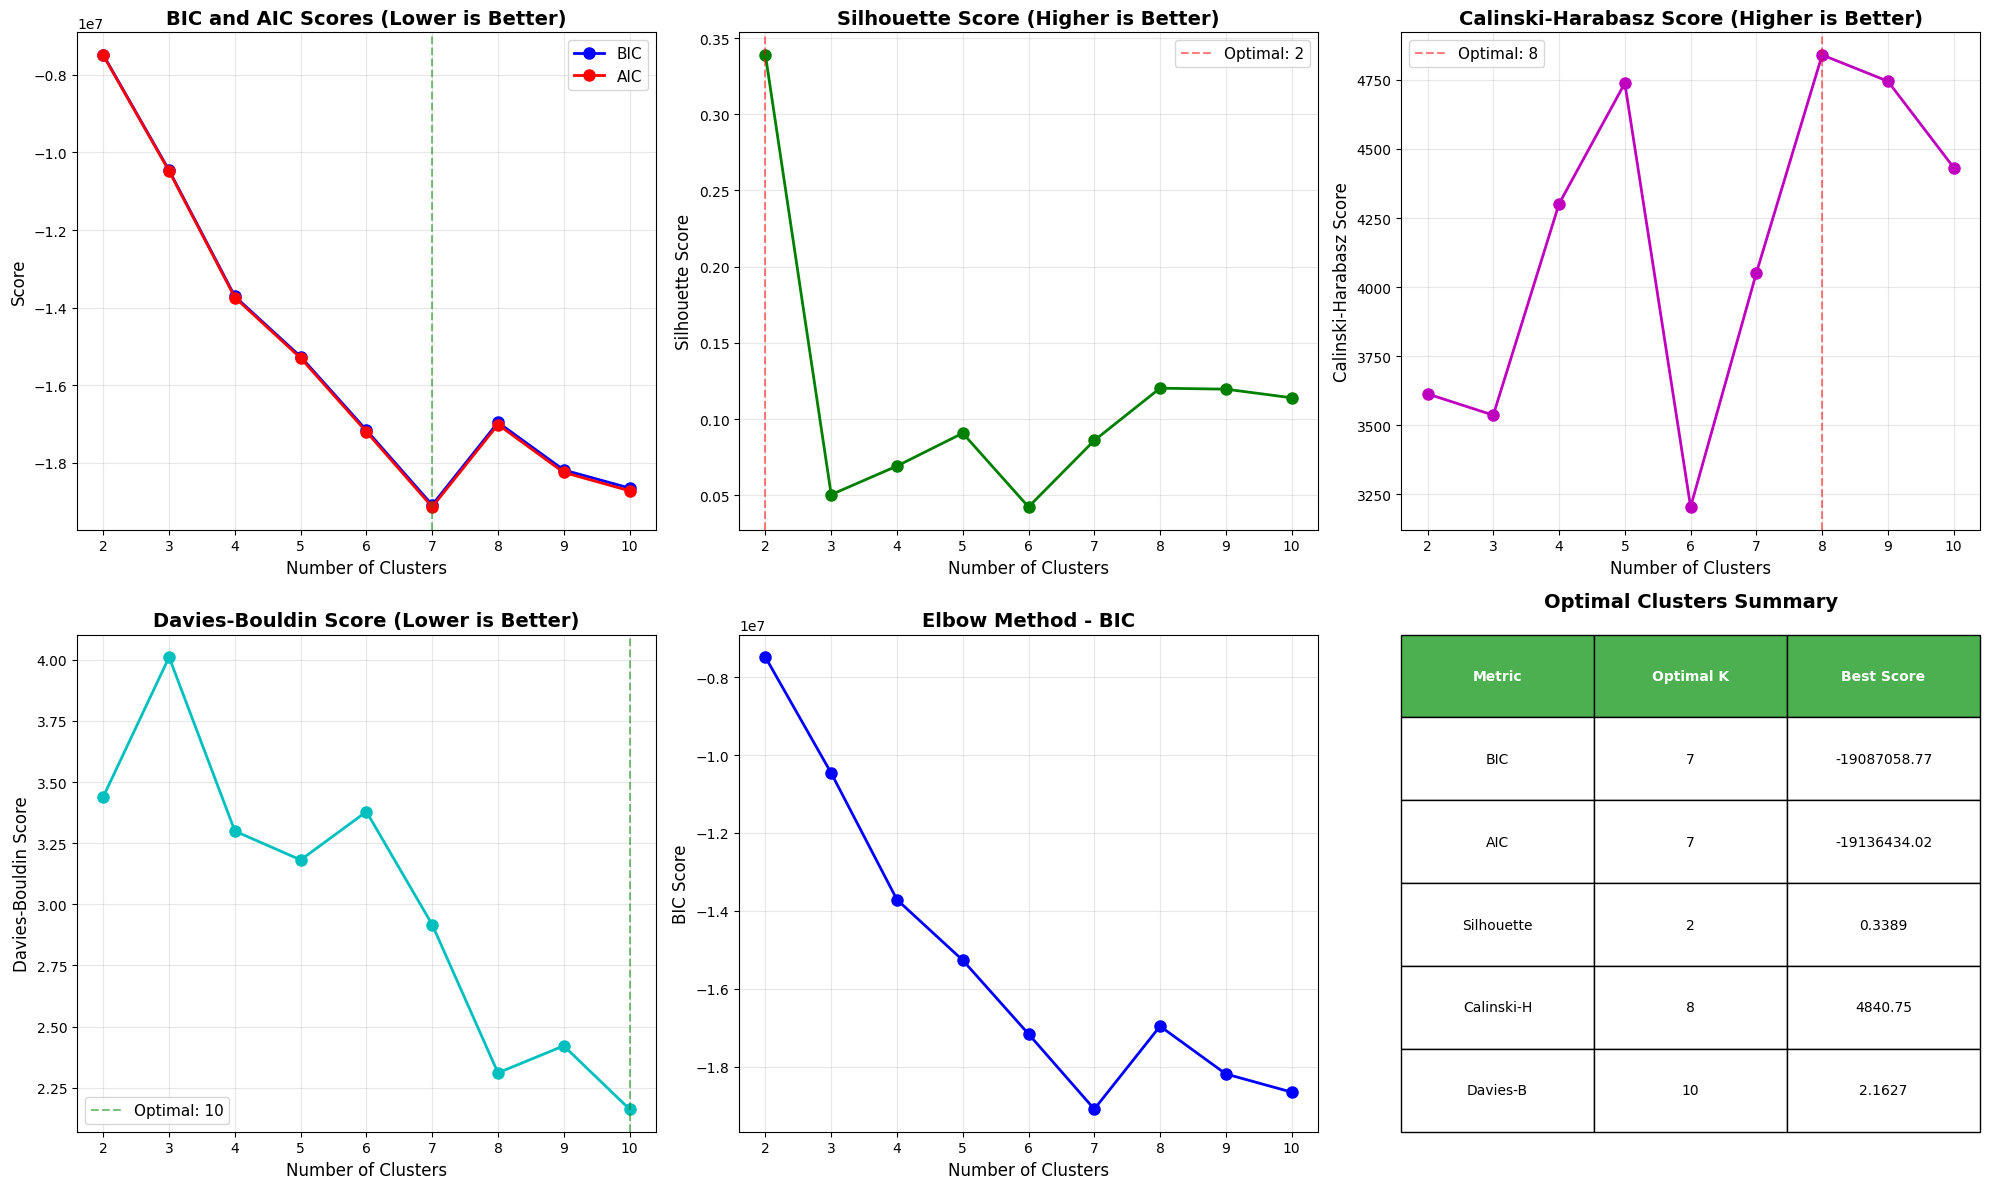

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# import pre-processed dataset
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop useless columns
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

# Prepare features for clustering (exclude non-numeric and identifier columns)
X = df.copy()

# Standardize the features
print("\nStandardizing features")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# 1. DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================
print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

n_components_range = range(2, 11)
bic_scores = []
aic_scores = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for n in n_components_range:
    print(f"Testing {n} clusters...")
    gmm = GaussianMixture(n_components=n, covariance_type='full', 
                          random_state=3244, n_init=10)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

# ============================================
# 2. CREATE EVALUATION PLOTS
# ============================================
print("\nCreating evaluation plots...")

fig = plt.figure(figsize=(20, 12))

# Plot 1: BIC and AIC scores
ax1 = plt.subplot(2, 3, 1)
ax1.plot(n_components_range, bic_scores, 'bo-', label='BIC', linewidth=2, markersize=8)
ax1.plot(n_components_range, aic_scores, 'ro-', label='AIC', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('BIC and AIC Scores (Lower is Better)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
optimal_bic = n_components_range[np.argmin(bic_scores)]
ax1.axvline(optimal_bic, color='green', linestyle='--', alpha=0.5, label=f'Optimal (BIC): {optimal_bic}')

# Plot 2: Silhouette Score
ax2 = plt.subplot(2, 3, 2)
ax2.plot(n_components_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
optimal_silhouette = n_components_range[np.argmax(silhouette_scores)]
ax2.axvline(optimal_silhouette, color='red', linestyle='--', alpha=0.5, label=f'Optimal: {optimal_silhouette}')
ax2.legend(fontsize=11)

# Plot 3: Calinski-Harabasz Score
ax3 = plt.subplot(2, 3, 3)
ax3.plot(n_components_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
ax3.set_xlabel('Number of Clusters', fontsize=12)
ax3.set_ylabel('Calinski-Harabasz Score', fontsize=12)
ax3.set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
optimal_calinski = n_components_range[np.argmax(calinski_scores)]
ax3.axvline(optimal_calinski, color='red', linestyle='--', alpha=0.5, label=f'Optimal: {optimal_calinski}')
ax3.legend(fontsize=11)

# Plot 4: Davies-Bouldin Score
ax4 = plt.subplot(2, 3, 4)
ax4.plot(n_components_range, davies_bouldin_scores, 'co-', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Clusters', fontsize=12)
ax4.set_ylabel('Davies-Bouldin Score', fontsize=12)
ax4.set_title('Davies-Bouldin Score (Lower is Better)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
optimal_db = n_components_range[np.argmin(davies_bouldin_scores)]
ax4.axvline(optimal_db, color='green', linestyle='--', alpha=0.5, label=f'Optimal: {optimal_db}')
ax4.legend(fontsize=11)

# Plot 5: Elbow method visualization (BIC)
ax5 = plt.subplot(2, 3, 5)
ax5.plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
ax5.set_xlabel('Number of Clusters', fontsize=12)
ax5.set_ylabel('BIC Score', fontsize=12)
ax5.set_title('Elbow Method - BIC', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Summary table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_data = {
    'Metric': ['BIC', 'AIC', 'Silhouette', 'Calinski-H', 'Davies-B'],
    'Optimal K': [optimal_bic, n_components_range[np.argmin(aic_scores)], 
                  optimal_silhouette, optimal_calinski, optimal_db],
    'Best Score': [f'{min(bic_scores):.2f}', f'{min(aic_scores):.2f}',
                   f'{max(silhouette_scores):.4f}', f'{max(calinski_scores):.2f}',
                   f'{min(davies_bouldin_scores):.4f}']
}
summary_df = pd.DataFrame(summary_data)
table = ax6.table(cellText=summary_df.values, colLabels=summary_df.columns,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax6.set_title('Optimal Clusters Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

# ============================================
# 3. FIT OPTIMAL GMM MODEL
# ============================================
# Use the most commonly suggested number (or BIC as default)
optimal_k = optimal_bic
print(f"\n{'='*60}")
print(f"FITTING GMM WITH {optimal_k} CLUSTERS (based on BIC)")
print(f"{'='*60}")

gmm_final = GaussianMixture(n_components=optimal_k, covariance_type='full', 
                             random_state=42, n_init=20)
gmm_final.fit(X_scaled)
labels = gmm_final.predict(X_scaled)
probabilities = gmm_final.predict_proba(X_scaled)

# Add results to dataframe
df['Cluster'] = labels
df['Cluster_Probability'] = probabilities.max(axis=1)

print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# ============================================
# 4. PCA VISUALIZATION
# ============================================
print("\nPerforming PCA for visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f"Explained variance by first 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

# Create PCA plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters in PCA space
scatter = axes[0].scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], 
                         cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
axes[0].set_title('GMM Clusters in PCA Space', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

# Plot 2: Cluster probability
scatter2 = axes[1].scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Probability'], 
                          cmap='RdYlGn', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
axes[1].set_title('Cluster Assignment Probability', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Probability')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# ============================================
# 5. CLUSTER CHARACTERISTICS
# ============================================
print("\nAnalyzing cluster characteristics...")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Cluster sizes
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Cluster', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cluster_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Average age by cluster
if 'Age' in df.columns:
    age_by_cluster = df.groupby('Cluster')['Age'].mean()
    axes[0, 1].bar(age_by_cluster.index, age_by_cluster.values, color='coral', edgecolor='black')
    axes[0, 1].set_xlabel('Cluster', fontsize=12)
    axes[0, 1].set_ylabel('Average Age', fontsize=12)
    axes[0, 1].set_title('Average Age by Cluster', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(age_by_cluster.values):
        axes[0, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Cluster probability distribution
axes[1, 0].hist(df['Cluster_Probability'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Assignment Probability', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Cluster Assignment Probabilities', fontsize=14, fontweight='bold')
axes[1, 0].axvline(df['Cluster_Probability'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["Cluster_Probability"].mean():.3f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of key features by cluster
key_features = ['Age', 'Reason_Suicide', 'Reason_Homicide', 'Reason_Accidental', 
                'Sex_Male', 'Race_White', 'Race_Black', 'Place of incident_Home']
key_features = [f for f in key_features if f in df.columns]

cluster_profiles = df.groupby('Cluster')[key_features].mean()
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=axes[1, 1], cbar_kws={'label': 'Mean Value'})
axes[1, 1].set_title('Cluster Profiles (Key Features)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Features', fontsize=12)

plt.tight_layout()

# ============================================
# 6. DETAILED CLUSTER COMPARISON
# ============================================
print("\nCreating detailed cluster comparison...")

# Select top features with most variance across clusters
feature_variance = df.groupby('Cluster')[feature_cols].mean().var()
top_features = feature_variance.nlargest(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    cluster_means = df.groupby('Cluster')[feature].mean()
    axes[idx].bar(cluster_means.index, cluster_means.values, 
                  color=plt.cm.Set3(np.arange(len(cluster_means))), edgecolor='black')
    axes[idx].set_xlabel('Cluster', fontsize=10)
    axes[idx].set_ylabel('Mean Value', fontsize=10)
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Top 12 Discriminating Features Across Clusters', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# ============================================
# 8. SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("CLUSTERING SUMMARY")
print("="*60)
print(f"Optimal number of clusters: {optimal_k}")
print(f"Total samples: {len(df)}")
print(f"\nFinal Model Metrics:")
print(f"  - BIC Score: {gmm_final.bic(X_scaled):.2f}")
print(f"  - AIC Score: {gmm_final.aic(X_scaled):.2f}")
print(f"  - Log Likelihood: {gmm_final.score(X_scaled):.2f}")
print(f"  - Silhouette Score: {silhouette_score(X_scaled, labels):.4f}")
print(f"  - Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, labels):.2f}")
print(f"  - Davies-Bouldin Score: {davies_bouldin_score(X_scaled, labels):.4f}")
print(f"\nMean cluster assignment probability: {df['Cluster_Probability'].mean():.4f}")
print(f"Samples with high confidence (>0.9): {(df['Cluster_Probability'] > 0.9).sum()} ({(df['Cluster_Probability'] > 0.9).sum()/len(df)*100:.1f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)


DATASET INFO
Samples: 100798
Features: 37
Features/Samples ratio: 0.00
Missing values: 0

Standardizing features...
Scaled data mean: -0.000000 (should be ~0)
Scaled data std: 1.000000 (should be ~1)

FINDING OPTIMAL NUMBER OF CLUSTERS
Testing 2 clusters...
  Cluster sizes: {0: 7731, 1: 93067}
Testing 3 clusters...
  Cluster sizes: {0: 5455, 1: 6594, 2: 88749}
Testing 4 clusters...
  Cluster sizes: {0: 3439, 1: 16843, 2: 77239, 3: 3277}
Testing 5 clusters...
  Cluster sizes: {0: 9273, 1: 14286, 2: 42090, 3: 14840, 4: 20309}
Testing 6 clusters...
  Cluster sizes: {0: 27029, 1: 4740, 2: 14547, 3: 9733, 4: 44621, 5: 128}
Testing 7 clusters...
  Cluster sizes: {0: 10308, 1: 10978, 2: 5035, 3: 11121, 4: 21449, 5: 39851, 6: 2056}
Testing 8 clusters...
  Cluster sizes: {0: 8773, 1: 9309, 2: 37025, 3: 11007, 4: 2569, 5: 18824, 6: 1326, 7: 11965}
Testing 9 clusters...
  Cluster sizes: {0: 10929, 1: 16729, 2: 1734, 3: 1391, 4: 11935, 5: 31001, 6: 1627, 7: 24156, 8: 1296}
Testing 10 clusters...


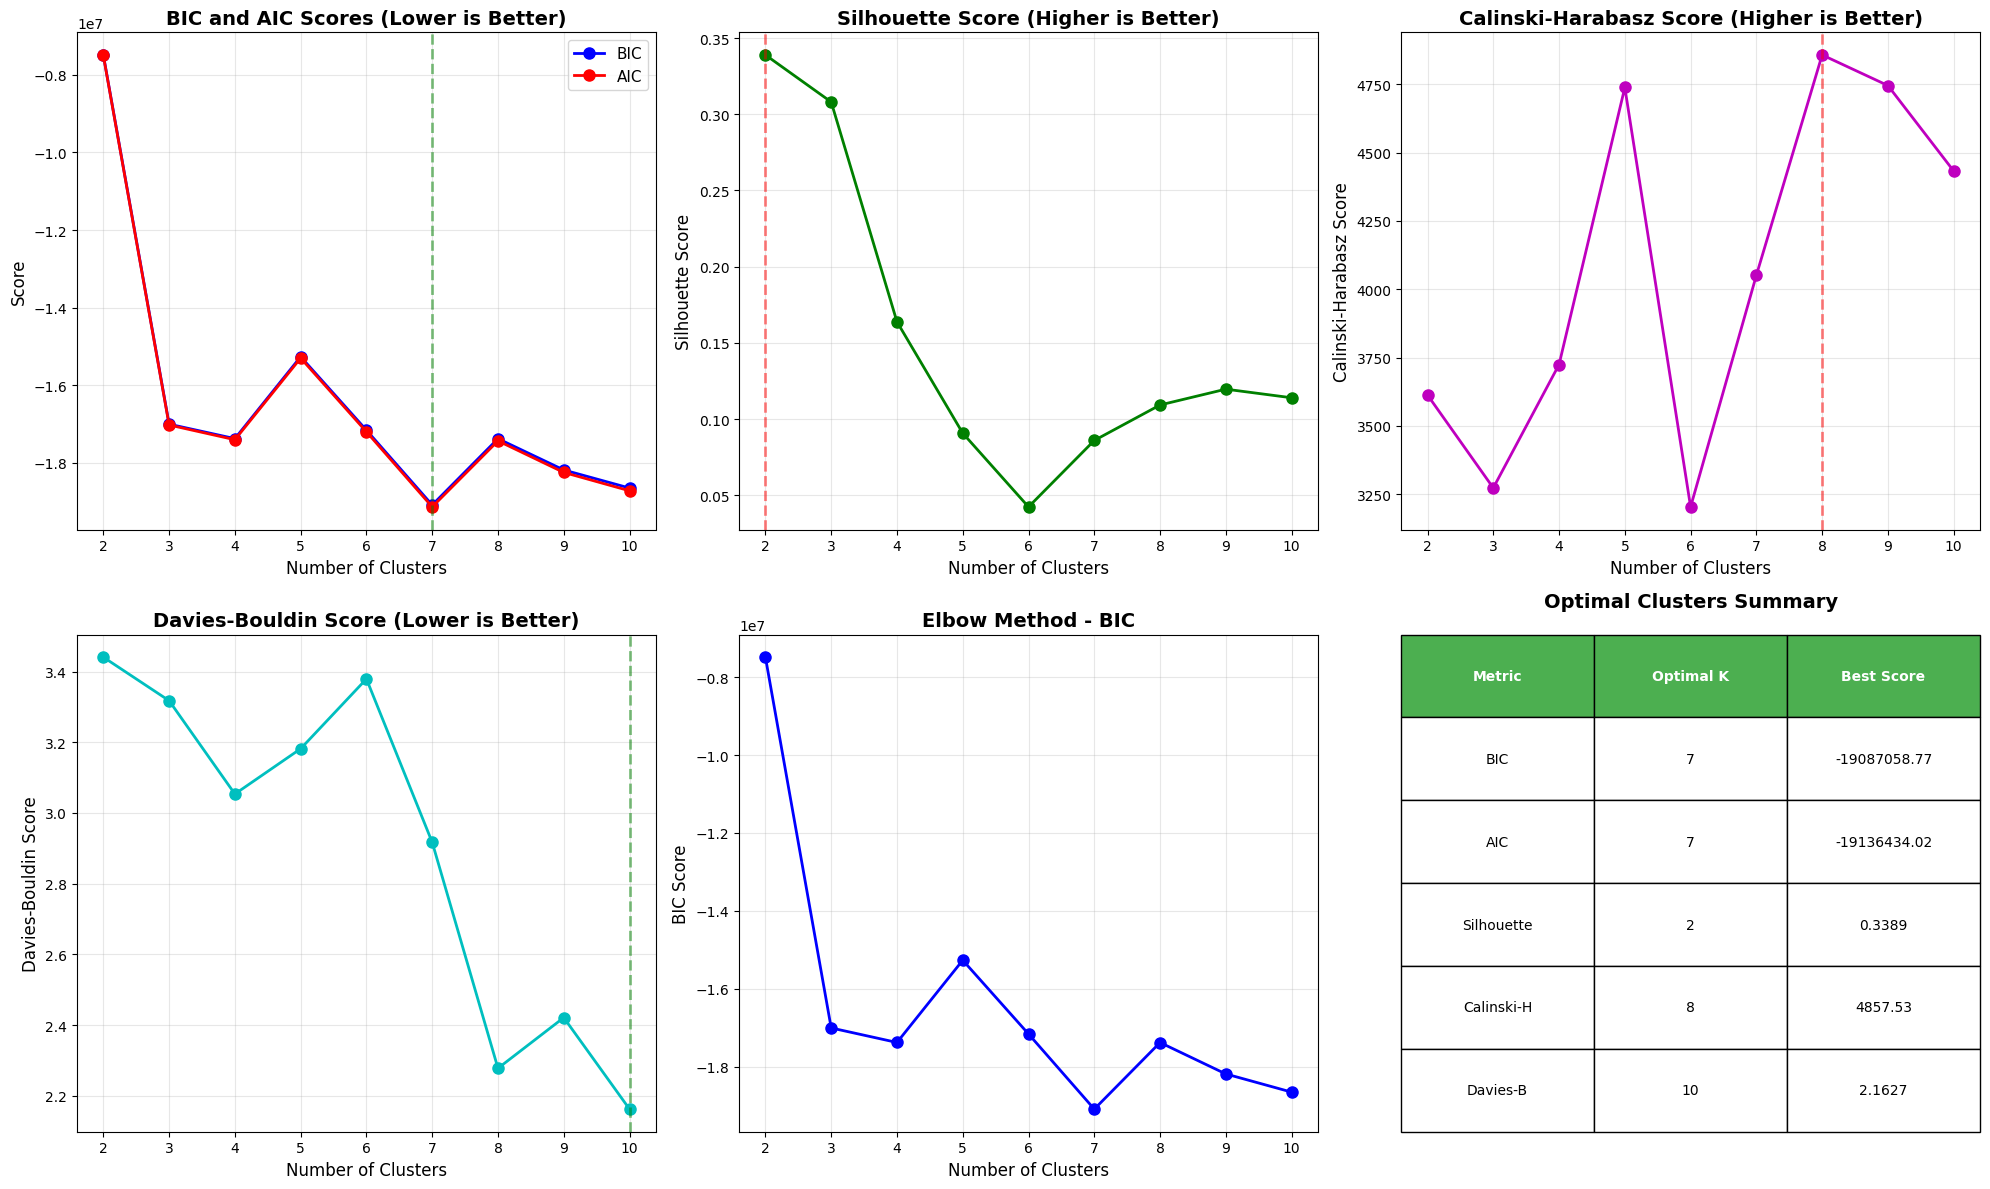


FITTING GMM WITH 7 CLUSTERS (based on BIC)

Cluster distribution:
Cluster
0    10308
1    10978
2     5035
3    11121
4    21449
5    39851
6     2056
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# import pre-processed dataset
df = pd.read_csv("../data/processed/guns_encoded.csv")

# Drop useless columns
df = df.drop(columns=['S.No.', 'Year', 'Month', 'Date', 'Hispanic'], errors='ignore')

# Store original feature names BEFORE any modifications
feature_cols = df.columns.tolist()

# Prepare features for clustering
X = df.copy()

print(f"\n{'='*60}")
print(f"DATASET INFO")
print(f"{'='*60}")
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Features/Samples ratio: {X.shape[1]/X.shape[0]:.2f}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Standardize the features
print("\nStandardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify scaling
print(f"Scaled data mean: {X_scaled.mean():.6f} (should be ~0)")
print(f"Scaled data std: {X_scaled.std():.6f} (should be ~1)")

# ============================================
# 1. DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================
print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

n_components_range = range(2, 11)
bic_scores = []
aic_scores = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

# Set random seed for reproducibility
np.random.seed(3244)

for n in n_components_range:
    print(f"Testing {n} clusters...")
    
    # Fit GMM with multiple initializations
    gmm = GaussianMixture(
        n_components=n, 
        covariance_type='full', 
        random_state=3244, 
        n_init=20,  # Increased from 10
        max_iter=20,  # Ensure convergence
        tol=1e-4
    )
    
    # Check for convergence
    gmm.fit(X_scaled)
    
    if not gmm.converged_:
        print(f"  WARNING: GMM did not converge for {n} clusters!")
    
    labels = gmm.predict(X_scaled)
    
    # Check cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  Cluster sizes: {dict(zip(unique, counts))}")
    
    # Store scores
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    
    # Only compute clustering metrics if we have at least 2 clusters with samples
    if len(unique) >= 2 and min(counts) >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    else:
        print(f"  WARNING: Degenerate clustering detected!")
        silhouette_scores.append(np.nan)
        calinski_scores.append(np.nan)
        davies_bouldin_scores.append(np.nan)

# Print score progressions
print("\n" + "="*60)
print("SCORE PROGRESSIONS")
print("="*60)
print("K  | BIC          | AIC          | Silhouette | Calinski-H | Davies-B")
print("-"*75)
for i, n in enumerate(n_components_range):
    print(f"{n:2d} | {bic_scores[i]:12.2f} | {aic_scores[i]:12.2f} | "
          f"{silhouette_scores[i]:10.4f} | {calinski_scores[i]:10.2f} | {davies_bouldin_scores[i]:8.4f}")

# ============================================
# 2. CREATE EVALUATION PLOTS
# ============================================
print("\nCreating evaluation plots...")

fig = plt.figure(figsize=(20, 12))

# Plot 1: BIC and AIC scores
ax1 = plt.subplot(2, 3, 1)
ax1.plot(n_components_range, bic_scores, 'bo-', label='BIC', linewidth=2, markersize=8)
ax1.plot(n_components_range, aic_scores, 'ro-', label='AIC', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('BIC and AIC Scores (Lower is Better)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
optimal_bic = n_components_range[np.argmin(bic_scores)]
ax1.axvline(optimal_bic, color='green', linestyle='--', alpha=0.5, linewidth=2)

# Plot 2: Silhouette Score
ax2 = plt.subplot(2, 3, 2)
# Filter out NaN values for plotting
valid_silhouette = [(k, s) for k, s in zip(n_components_range, silhouette_scores) if not np.isnan(s)]
if valid_silhouette:
    ks, ss = zip(*valid_silhouette)
    ax2.plot(ks, ss, 'go-', linewidth=2, markersize=8)
    optimal_silhouette = ks[np.argmax(ss)]
    ax2.axvline(optimal_silhouette, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Number of Clusters', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Calinski-Harabasz Score
ax3 = plt.subplot(2, 3, 3)
valid_calinski = [(k, s) for k, s in zip(n_components_range, calinski_scores) if not np.isnan(s)]
if valid_calinski:
    kc, cs = zip(*valid_calinski)
    ax3.plot(kc, cs, 'mo-', linewidth=2, markersize=8)
    optimal_calinski = kc[np.argmax(cs)]
    ax3.axvline(optimal_calinski, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax3.set_xlabel('Number of Clusters', fontsize=12)
ax3.set_ylabel('Calinski-Harabasz Score', fontsize=12)
ax3.set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Davies-Bouldin Score
ax4 = plt.subplot(2, 3, 4)
valid_db = [(k, s) for k, s in zip(n_components_range, davies_bouldin_scores) if not np.isnan(s)]
if valid_db:
    kd, ds = zip(*valid_db)
    ax4.plot(kd, ds, 'co-', linewidth=2, markersize=8)
    optimal_db = kd[np.argmin(ds)]
    ax4.axvline(optimal_db, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax4.set_xlabel('Number of Clusters', fontsize=12)
ax4.set_ylabel('Davies-Bouldin Score', fontsize=12)
ax4.set_title('Davies-Bouldin Score (Lower is Better)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Elbow method visualization (BIC)
ax5 = plt.subplot(2, 3, 5)
ax5.plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
ax5.set_xlabel('Number of Clusters', fontsize=12)
ax5.set_ylabel('BIC Score', fontsize=12)
ax5.set_title('Elbow Method - BIC', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Summary table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_data = {
    'Metric': ['BIC', 'AIC', 'Silhouette', 'Calinski-H', 'Davies-B'],
    'Optimal K': [
        optimal_bic, 
        n_components_range[np.argmin(aic_scores)],
        optimal_silhouette if valid_silhouette else 'N/A',
        optimal_calinski if valid_calinski else 'N/A',
        optimal_db if valid_db else 'N/A'
    ],
    'Best Score': [
        f'{min(bic_scores):.2f}', 
        f'{min(aic_scores):.2f}',
        f'{max([s for s in silhouette_scores if not np.isnan(s)]):.4f}' if valid_silhouette else 'N/A',
        f'{max([s for s in calinski_scores if not np.isnan(s)]):.2f}' if valid_calinski else 'N/A',
        f'{min([s for s in davies_bouldin_scores if not np.isnan(s)]):.4f}' if valid_db else 'N/A'
    ]
}
summary_df = pd.DataFrame(summary_data)
table = ax6.table(cellText=summary_df.values, colLabels=summary_df.columns,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax6.set_title('Optimal Clusters Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================
# 3. FIT OPTIMAL GMM MODEL
# ============================================
optimal_k = optimal_bic
print(f"\n{'='*60}")
print(f"FITTING GMM WITH {optimal_k} CLUSTERS (based on BIC)")
print(f"{'='*60}")

gmm_final = GaussianMixture(
    n_components=optimal_k, 
    covariance_type='full', 
    random_state=3244,  # Use same seed
    n_init=50,  # More initializations for final model
    max_iter=300
)
gmm_final.fit(X_scaled)

if not gmm_final.converged_:
    print("WARNING: Final GMM did not converge!")

labels = gmm_final.predict(X_scaled)
probabilities = gmm_final.predict_proba(X_scaled)

# Add results to dataframe (make a fresh copy to avoid issues)
df_results = df.copy()
df_results['Cluster'] = labels
df_results['Cluster_Probability'] = probabilities.max(axis=1)

print(f"\nCluster distribution:")
print(df_results['Cluster'].value_counts().sort_index())

# Rest of your visualization code...

# Others

Best K: 3 silhouette: 0.185


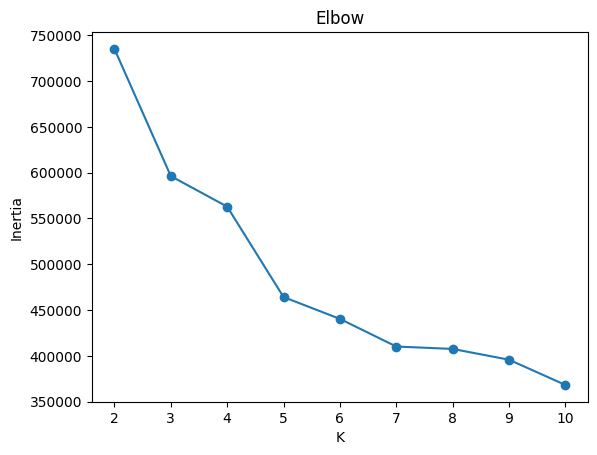

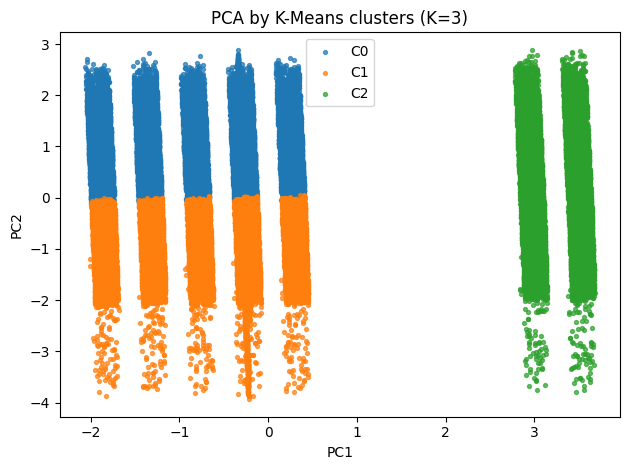

C:\Users\Beckh\AppData\Local\Temp\ipykernel_38004\1143278528.py:107: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)


,"(Age, count)","(Age, mean)","(Age, median)","(Police involvement, count)","(Police involvement, mean)","(Police involvement, median)",Race=Asian/Pacific Islander,Race=Black,Race=Hispanic,Race=Native American/Native Alaskan,...,Reason=Undetermined,AgeBucket=<=17,AgeBucket=18-25,AgeBucket=26-35,AgeBucket=36-45,AgeBucket=46-55,AgeBucket=56-65,AgeBucket=66+,Sex=Female,Sex=Male
cluster,,,,,,,,,,,,,,,,,,,,,
0,44549,60.46,59.0,44553,0.00,0.0,0.009,0.035,0.028,0.005,...,0.007,0.000,0.000,0.000,0.136,0.273,0.262,0.329,0.157,0.843
1,43868,29.08,28.0,43881,0.03,0.0,0.018,0.431,0.151,0.013,...,0.010,0.054,0.347,0.386,0.159,0.047,0.006,0.000,0.129,0.871
2,12363,44.64,42.0,12364,0.01,0.0,0.013,0.231,0.091,0.010,...,0.006,0.026,0.171,0.198,0.152,0.156,0.132,0.164,0.144,0.856


In [ ]:
# import libraries
import pandas as pd, numpy as np
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# import dataset
file_path = "../data/raw/Guns incident Data.csv"
df = pd.read_csv(file_path)

# basic cleaning (can remove and import cleaned dataset later)
df = df.replace({"NA": np.nan}) # replace NA
df["Age"] = pd.to_numeric(df["Age"], errors = "coerce")
df["Police involvement"] = pd.to_numeric(df["Police involvement"], errors="coerce")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# columns to keep
useful_cols = ["Date", "Reason", "Education", "Sex", "Age", "Race", "Place of incident", "Police involvement"]
df_copy = df[useful_cols].copy()

# --- Feature Engineering ---
bins = [-np.inf, 17, 25, 35, 45, 55, 65, np.inf]
labels = ["<=17","18-25","26-35","36-45","46-55","56-65","66+"]
df_copy["AgeBucket"] = pd.cut(df_copy["Age"], bins=bins, labels=labels)  # <-- use AgeBucket consistently

df_copy["Month"]   = df_copy["Date"].dt.month
df_copy["Weekday"] = df_copy["Date"].dt.weekday
df_copy["IsWeekend"] = df_copy["Weekday"].isin([5,6]).astype("float")

def combine_small_categories(s: pd.Series, min_count=700, other_label="Other"):
    counts = s.value_counts(dropna=True)
    keep = counts[counts >= min_count].index
    return s.where(s.isin(keep), other_label)

for col in ["Race","Education","Place of incident","Reason"]:
    df_copy[col] = combine_small_categories(df_copy[col], min_count=700)

# final feature set (match names exactly)
cat_features = ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]
num_features = ["Age","Month","Weekday","IsWeekend","Police involvement"]

df_cluster = df_copy[cat_features + num_features].copy()

# --- Preprocess ---
cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh" , OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # if older sklearn, use sparse=False
])

num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc" , StandardScaler())
])

# Use the SAME variable names you defined above
pre = ColumnTransformer([
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
], remainder="drop")

# --- Pick K (silhouette + elbow) and fit K-Means ---
df_pre = pre.fit_transform(df_cluster)

best_k, best_score, scores = None, -1, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels = km.fit_predict(df_pre)
    s = silhouette_score(df_pre, labels)
    scores[k] = s
    if s > best_score:
        best_k, best_score = k, s
print("Best K:", best_k, "silhouette:", round(best_score,3))

inertias = []
for k in range(2, 11):
    inertias.append(KMeans(n_clusters=k, n_init="auto", random_state=3244).fit(df_pre).inertia_)
plt.plot(range(2,11), inertias, marker="o"); plt.title("Elbow"); plt.xlabel("K"); plt.ylabel("Inertia"); plt.show()

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=3244)
labels = kmeans.fit_predict(df_pre)

# 2D PCA plot
pca = PCA(n_components=2, random_state=3244)
X_2d = pca.fit_transform(df_pre)
plot_df = pd.DataFrame({"PC1":X_2d[:,0], "PC2":X_2d[:,1], "cluster":labels})

for c in sorted(plot_df.cluster.unique()):
    sub = plot_df[plot_df.cluster==c]
    plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
plt.legend(); plt.title(f"PCA by K-Means clusters (K={best_k})")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# --- Cluster Profile Table ---
prof = df_copy.copy()
prof["cluster"] = labels

num_summary = prof.groupby("cluster")[["Age","Police involvement"]].agg(["count","mean","median"]).round(2)

def prop_table(col):
    tab = (prof.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

cat_summary = pd.concat([prop_table(c) for c in ["Race","Education","Place of incident","Reason","AgeBucket","Sex"]], axis=1)

cluster_profile = pd.concat([num_summary, cat_summary], axis=1).sort_index()
cluster_profile.head()



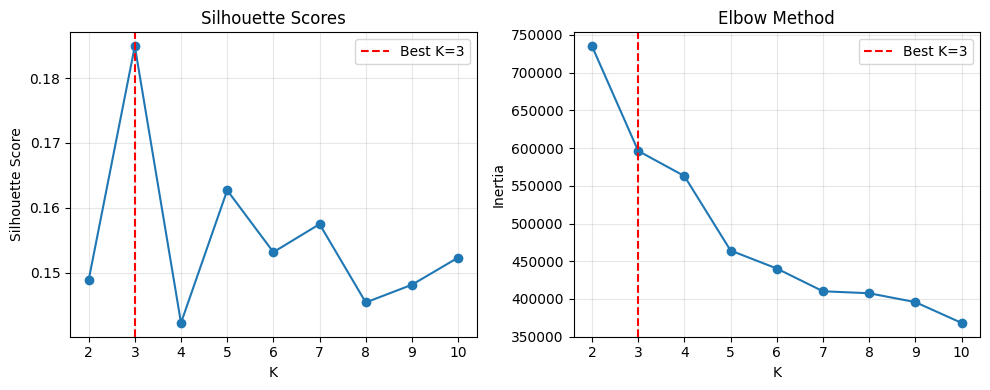


=== K-Means with K=5 ===


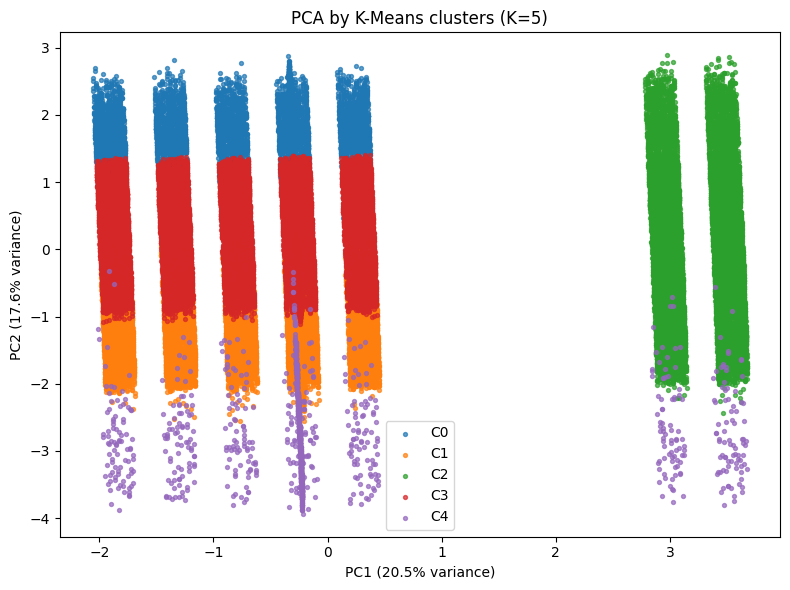


=== K-Means with K=6 ===


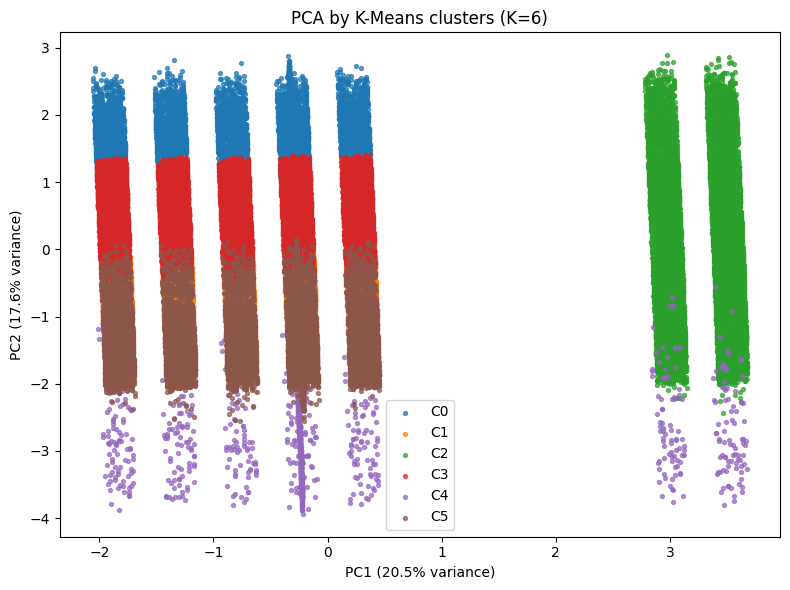


=== Cluster Profile for K=5 ===

Cluster sizes:
cluster
0    14654
1    28936
2    12199
3    43607
4     1402
Name: count, dtype: int64

=== Cluster Profile for K=6 ===

Cluster sizes:
cluster
0    14653
1    15860
2    12199
3    32304
4     1402
5    24380
Name: count, dtype: int64

=== COMPLETE Cluster Profile for K=5 ===
         (Age, count)  (Age, mean)  (Age, median)  \
cluster                                             
0               14654        76.57           75.0   
1               28928        28.96           27.0   
2               12198        44.76           42.0   
3               43598        45.02           47.0   
4                1402        37.05           35.0   

         (Police involvement, count)  (Police involvement, mean)  \
cluster                                                            
0                              14654                         0.0   
1                              28936                         0.0   
2                          

C:\Users\Beckh\AppData\Local\Temp\ipykernel_38004\2976649809.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
C:\Users\Beckh\AppData\Local\Temp\ipykernel_38004\2976649809.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)


In [ ]:
# --- Additional analysis for k=5 and k=6 ---

# Recalculate inertias to ensure we have all values
inertias = []
for k in range(2, 11):
    km_temp = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    km_temp.fit(df_pre)
    inertias.append(km_temp.inertia_)

# Plot silhouette scores and elbow
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.title('Silhouette Scores')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), inertias, marker='o')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K={best_k}')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Function to plot PCA for a given k
def plot_kmeans_pca(k, df_pre, pca_model, X_2d):
    km = KMeans(n_clusters=k, n_init="auto", random_state=3244)
    labels_k = km.fit_predict(df_pre)
    
    plot_df_k = pd.DataFrame({"PC1": X_2d[:, 0], "PC2": X_2d[:, 1], "cluster": labels_k})
    
    plt.figure(figsize=(8, 6))
    for c in sorted(plot_df_k.cluster.unique()):
        sub = plot_df_k[plot_df_k.cluster == c]
        plt.scatter(sub.PC1, sub.PC2, s=8, alpha=0.7, label=f"C{c}")
    plt.legend()
    plt.title(f"PCA by K-Means clusters (K={k})")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.tight_layout()
    plt.show()
    
    return labels_k

# Plot for k=5
print("\n=== K-Means with K=5 ===")
labels_5 = plot_kmeans_pca(5, df_pre, pca, X_2d)

# Plot for k=6
print("\n=== K-Means with K=6 ===")
labels_6 = plot_kmeans_pca(6, df_pre, pca, X_2d)

# Optional: Create cluster profiles for k=5 and k=6
def create_cluster_profile(labels_k, k_value):
    prof_k = df_copy.copy()
    prof_k["cluster"] = labels_k
    
    print(f"\n=== Cluster Profile for K={k_value} ===")
    print(f"\nCluster sizes:")
    print(prof_k["cluster"].value_counts().sort_index())
    
    num_summary_k = prof_k.groupby("cluster")[["Age", "Police involvement"]].agg(["count", "mean", "median"]).round(2)
    
    cat_summary_k = pd.concat([prop_table_k(c, prof_k) for c in ["Race", "Education", "Place of incident", "Reason", "AgeBucket", "Sex"]], axis=1)
    
    cluster_profile_k = pd.concat([num_summary_k, cat_summary_k], axis=1).sort_index()
    return cluster_profile_k

def prop_table_k(col, prof_k):
    tab = (prof_k.pivot_table(index="cluster", columns=col, values="Age", aggfunc="size", fill_value=0)
              .apply(lambda r: r/r.sum(), axis=1))
    tab.columns = [f"{col}={c}" for c in tab.columns]
    return tab.round(3)

# Generate profiles
profile_5 = create_cluster_profile(labels_5, 5)
profile_6 = create_cluster_profile(labels_6, 6)

# Display full profiles
print("\n=== COMPLETE Cluster Profile for K=5 ===")
print(profile_5)

print("\n=== COMPLETE Cluster Profile for K=6 ===")
print(profile_6)

# Summary

## Summary of K-Means Clustering Results
### K=5 Clustering
Cluster Characteristics:

**Cluster 0 (n=14,654 - 15%) - Elderly Suicide Victims**

Age: Mean 76.6 years, all 66+ years old
Demographics: 89% Male, predominantly White (93%)
Key Feature: Oldest cluster, represents senior citizens
Police Involvement: 0%

**Cluster 1 (n=28,936 - 29%) - Young Black Homicide Victims**

Age: Mean 29.0 years (56% are 18-25, 34% are 26-35)
Demographics: 88% Male, 63% Black, 19% Hispanic
Key Feature: Youngest cluster with highest proportion of Black victims
Police Involvement: 0%

**Cluster 2 (n=12,199 - 12%) - Middle-Aged Mixed Demographics**

Age: Mean 44.8 years (fairly evenly distributed across 26-65)
Demographics: 86% Male, 23% Black, 65% White
Key Feature: Most age-diverse cluster
Police Involvement: 0%

**Cluster 3 (n=43,607 - 43%) - Middle-Aged White Suicide Victims**

Age: Mean 45.0 years (peak at 46-65 age range)
Demographics: 83% Male, predominantly White (91%)
Key Feature: Largest cluster, mainly middle-aged White males
Police Involvement: 0%

**Cluster 4 (n=1,402 - 1%) - Police-Involved Shootings**

Age: Mean 37.1 years (31% are 26-35, 23% are 36-45)
Demographics: 96% Male, 25% Black, 20% Hispanic, 49% White
Key Feature: ONLY cluster with police involvement (100%)
Police Involvement: 100%

### K=6 Clustering
K=6 essentially splits Cluster 1 from K=5 into two groups:
New Cluster 1 (n=15,860) - Very Young Victims

Age: Mean 26.0 years (81% under 17 or 18-25, with 53% being 26-35)
Demographics: More diverse, 85% Male, only 8% Black

New Cluster 5 (n=24,380) - Young Black Homicide Victims

Age: Mean 29.6 years (similar to original Cluster 1)
Demographics: 89% Male, 70% Black (concentrated Black population)
Key Feature: Separates out predominantly Black young victims

All other clusters (0, 2, 3, 4) remain essentially identical to K=5.

Key Insights

Police-involved shootings form a distinct, small cluster (Cluster 4) across both K=5 and K=6
Age is a strong differentiator: Clear separation between elderly (66+), middle-aged (36-65), and young adults (18-35)
Race patterns vary by age: Young victims are disproportionately Black, while elderly victims are predominantly White
Gender: All clusters are 80-96% male
K=6 provides additional granularity by separating young Black victims from other young victims, which may be valuable for understanding racial disparities in gun violence

Recommendation: K=5 appears sufficient for most analyses, but K=6 may be preferred if racial disparities among young victims are a key focus of the analysis.

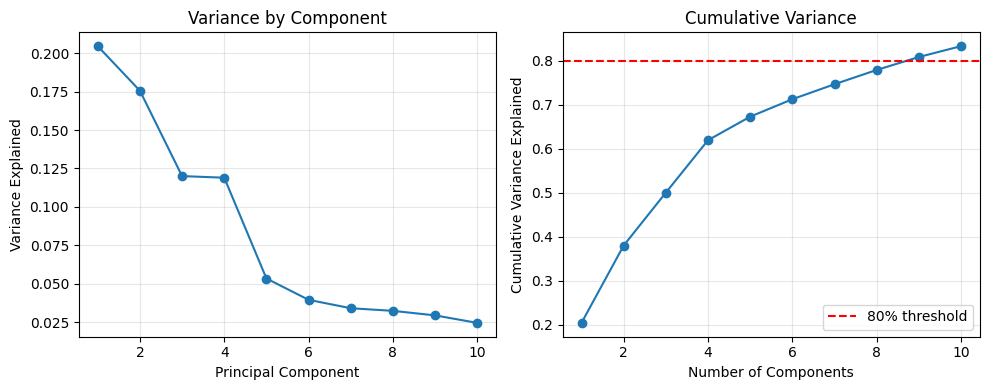

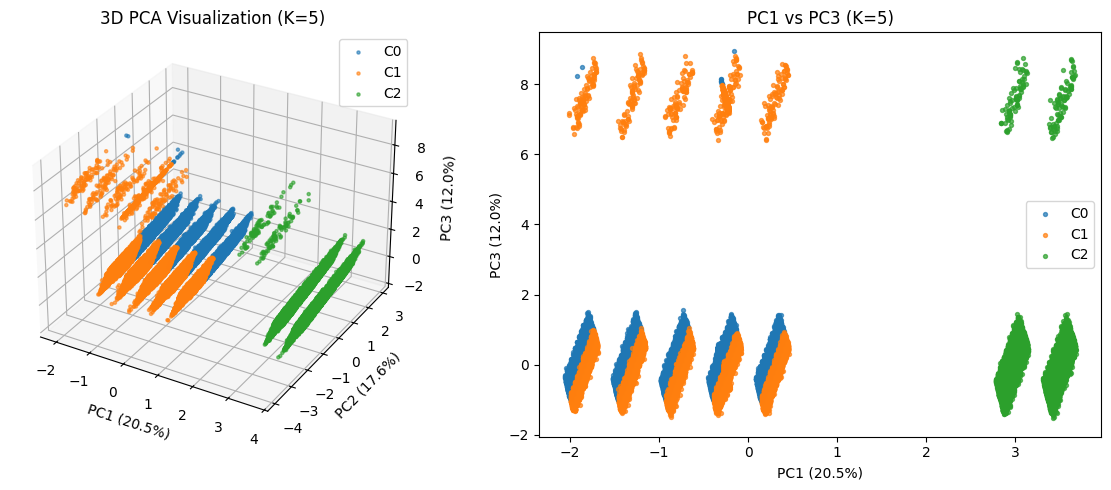

In [ ]:
# 1. Show variance explained by more components
pca_full = PCA(random_state=3244)
pca_full.fit(df_pre)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), pca_full.explained_variance_ratio_[:10], marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance by Component')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, 11), cum_var[:10], marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Try 3D PCA plot for better separation
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=3244)
X_3d = pca_3d.fit_transform(df_pre)

fig = plt.figure(figsize=(12, 5))

# 3D view
ax1 = fig.add_subplot(121, projection='3d')
for c in sorted(set(labels)):
    mask = labels == c
    ax1.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2], 
                s=5, alpha=0.6, label=f'C{c}')
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax1.set_title('3D PCA Visualization (K=5)')
ax1.legend()

# PC1 vs PC3 (might show better separation)
ax2 = fig.add_subplot(122)
for c in sorted(set(labels)):
    mask = labels == c
    ax2.scatter(X_3d[mask, 0], X_3d[mask, 2], s=8, alpha=0.7, label=f'C{c}')
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax2.set_title('PC1 vs PC3 (K=5)')
ax2.legend()
plt.tight_layout()
plt.show()

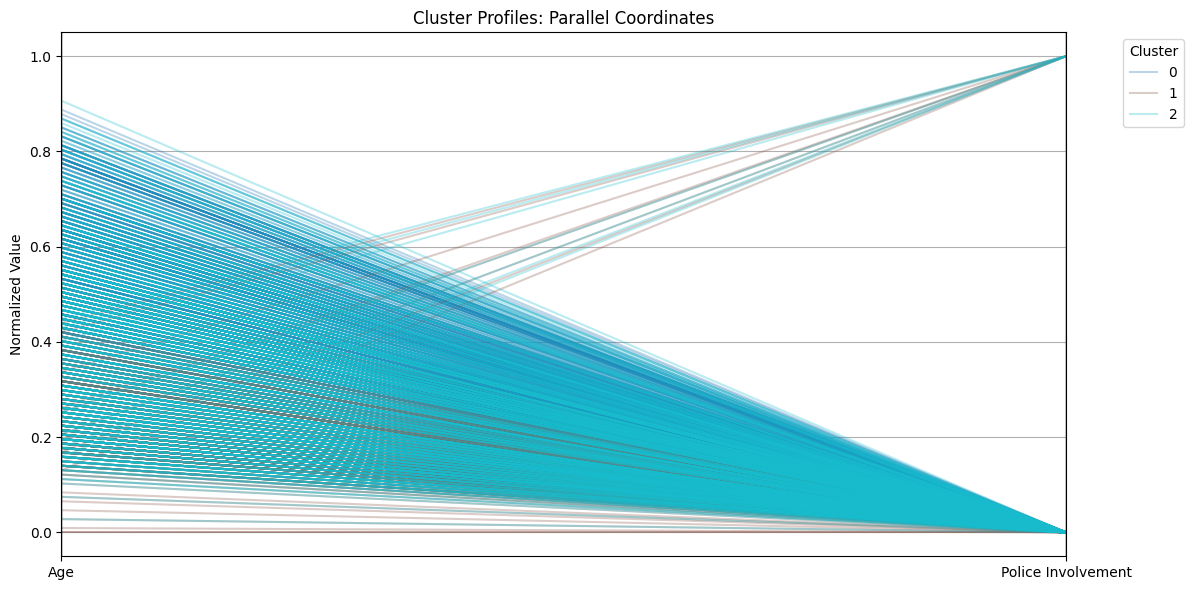

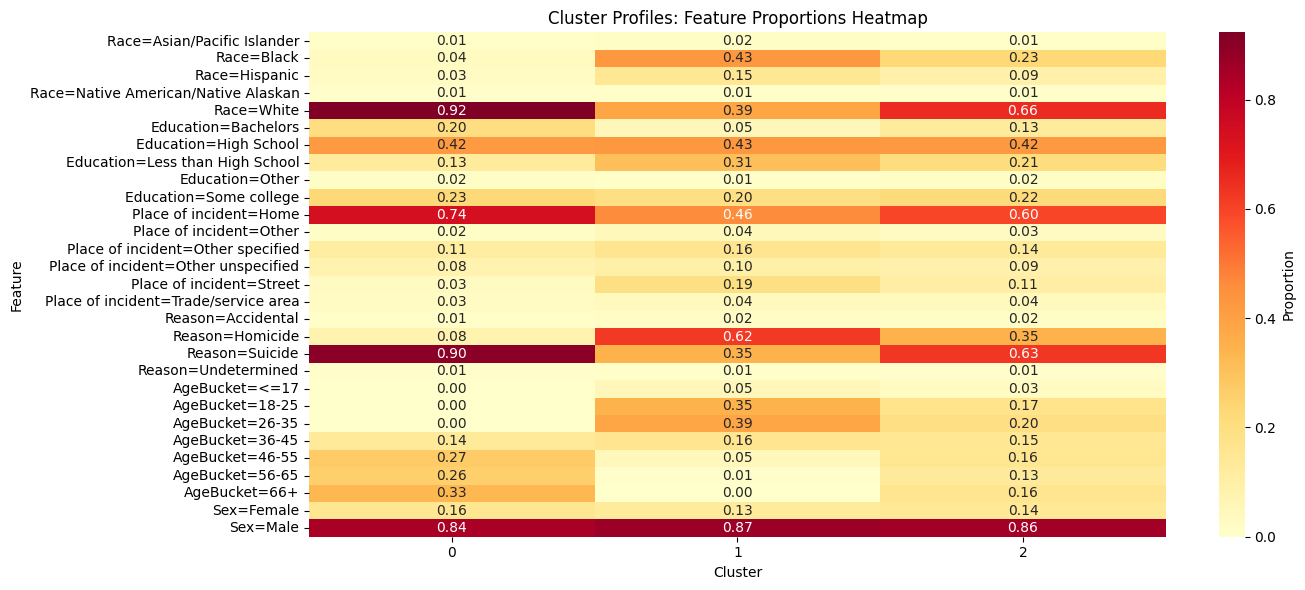

In [ ]:
# Parallel coordinates plot - shows cluster profiles across features
from pandas.plotting import parallel_coordinates
import seaborn as sns

# Select key features for visualization
viz_df = df_copy.copy()
viz_df['cluster'] = labels

# Normalize numerical features for comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
viz_df[['Age_norm', 'Police_norm']] = scaler.fit_transform(viz_df[['Age', 'Police involvement']])

# Create sample for cleaner visualization
sample_df = viz_df.groupby('cluster').sample(n=500, random_state=3244)

plt.figure(figsize=(12, 6))
parallel_coordinates(sample_df[['Age_norm', 'Police_norm', 'cluster']], 
                    'cluster', colormap='tab10', alpha=0.3)
plt.title('Cluster Profiles: Parallel Coordinates')
plt.ylabel('Normalized Value')
plt.xticks([0, 1], ['Age', 'Police Involvement'])
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Feature importance heatmap
plt.figure(figsize=(14, 6))
profile_viz = cluster_profile.iloc[:, 6:].T  # categorical features only
sns.heatmap(profile_viz, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Proportion'})
plt.title('Cluster Profiles: Feature Proportions Heatmap')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Check cluster separation quality
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print(f"Silhouette Score: {silhouette_score(df_pre, labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(df_pre, labels):.3f} (lower is better)")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(df_pre, labels):.1f} (higher is better)")

Silhouette Score: 0.185
Davies-Bouldin Index: 1.825 (lower is better)
Calinski-Harabasz Score: 21035.9 (higher is better)


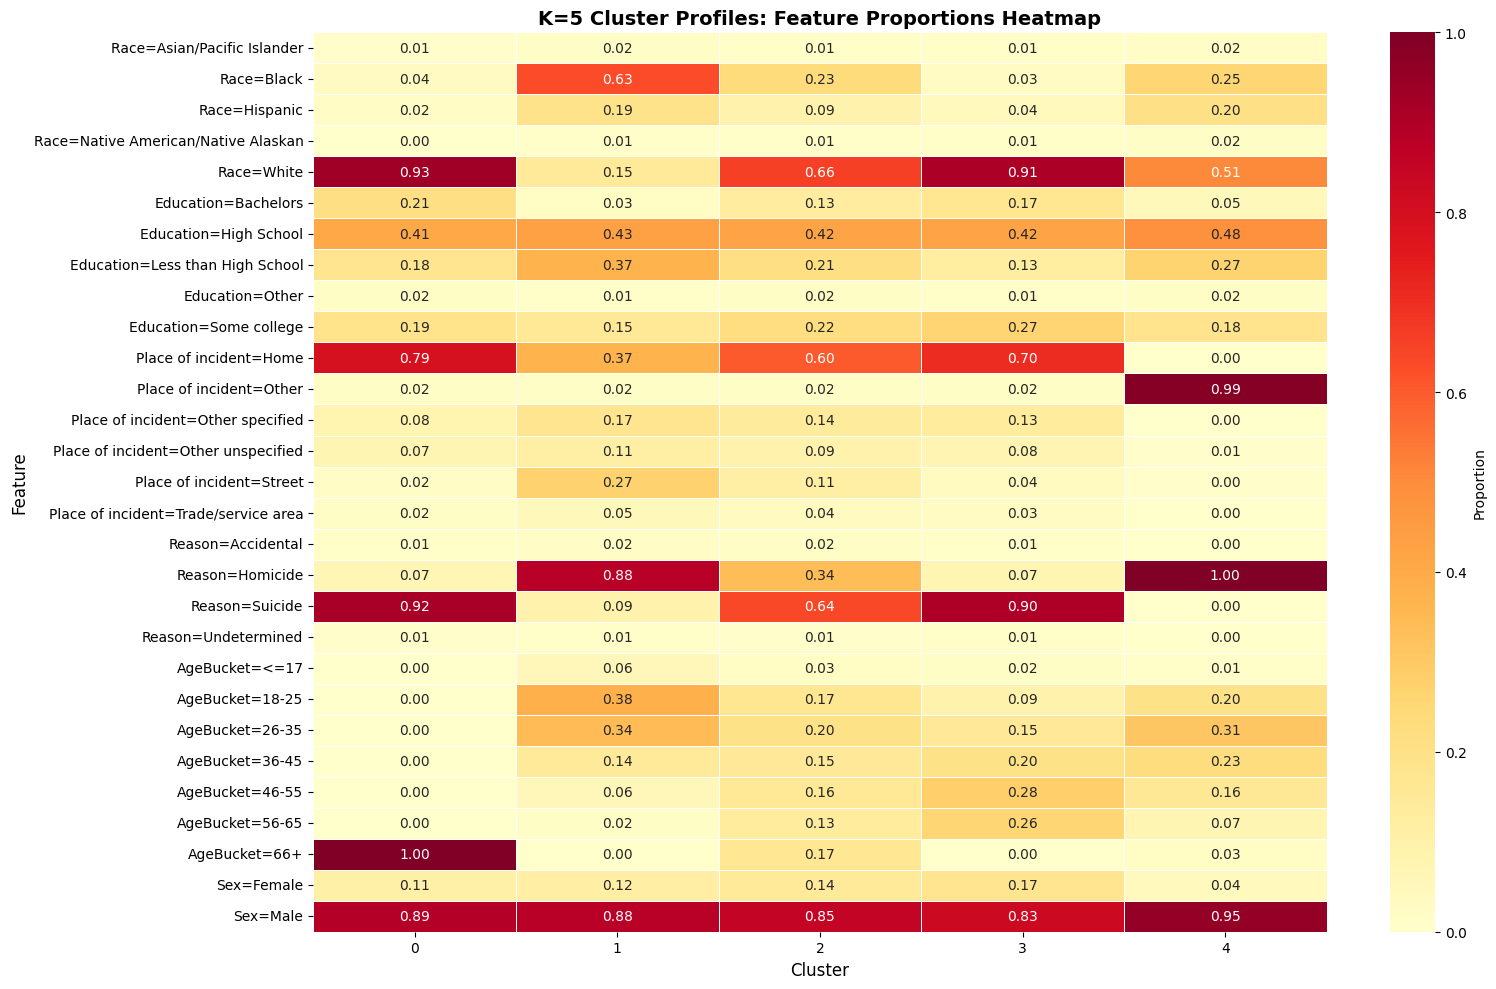

In [ ]:
import seaborn as sns

# Create heatmap for K=5 cluster profiles
plt.figure(figsize=(16, 10))
profile_viz_k5 = profile_5.iloc[:, 6:].T  # categorical features only (skip numerical summaries)

sns.heatmap(profile_viz_k5, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Proportion'}, linewidths=0.5)
plt.title('K=5 Cluster Profiles: Feature Proportions Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()